<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/2_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rain Prediction (Australia) - Data Cleaning & Feature Engineering

Handle missing values, engineer features, encode categoricals, save cleaned sataset.

#1. Imports & Load Raw Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [16]:
def load_data():
    print("Loading data...")
    return pd.DataFrame()

In [17]:
def preprocess_data(df):
    print("Preprocessing data...")
    return df.copy()

In [34]:
def create_features(df):
    print("Creating features...")
    df_copy = df.copy()

    # Convert 'Date' column to datetime objects
    df_copy['Date'] = pd.to_datetime(df_copy['Date'])

    # Time-based features
    df_copy['Year'] = df_copy['Date'].dt.year
    df_copy['Month'] = df_copy['Date'].dt.month
    df_copy['Day'] = df_copy['Date'].dt.day
    df_copy['DayOfWeek'] = df_copy['Date'].dt.dayofweek
    df_copy['Quarter'] = df_copy['Date'].dt.quarter
    df_copy['IsWeekend'] = ((df_copy['Date'].dt.dayofweek == 5) | (df_copy['Date'].dt.dayofweek == 6)).astype(int)

    # Interaction/Combined features
    df_copy['TempRange'] = df_copy['MaxTemp'] - df_copy['MinTemp']
    df_copy['AvgHumidity'] = (df_copy['Humidity9am'] + df_copy['Humidity3pm']) / 2
    df_copy['AvgPressure'] = (df_copy['Pressure9am'] + df_copy['Pressure3pm']) / 2
    df_copy['AvgWindSpeed'] = (df_copy['WindSpeed9am'] + df_copy['WindSpeed3pm']) / 2

    # Difference/Change features
    df_copy['PressureChange'] = df_copy['Pressure9am'] - df_copy['Pressure3pm']
    df_copy['HumidityChange'] = df_copy['Humidity9am'] - df_copy['Humidity3pm']

    return df_copy

In [14]:
from google.colab import files
uploaded = files.upload()

Saving weatherAUS.csv to weatherAUS.csv


In [19]:
df = pd.read_csv("weatherAUS.csv")
print(f"Raw shape:", df.shape)
df.head()

Raw shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


#2. Handle Missing / Invalid Values

In [23]:
missing = df.isnull().sum()
print('Remaining missing values per column (>0):')
print(missing[missing > 0].sort_values(ascending=False))
df_clean = df.copy()

Remaining missing values per column (>0):
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
dtype: int64


#3. Imputation

In [25]:
df_imputed = df_clean.copy()
for col in df_imputed.columns:
    if df_imputed[col].isnull().sum() > 0:
        if df_imputed[col].dtype.kind in 'fi':
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
        else:
          mode_values = df_imputed[col].mode()
          df_imputed[col] = df_imputed[col].fillna(mode_values.iloc[0] if not mode_values.empty else 'Unknown')
print('Missing after imputation:', df_imputed.isnull().sum().sum())

Missing after imputation: 0


#4. Distribution Comparison Before vs After Imputation

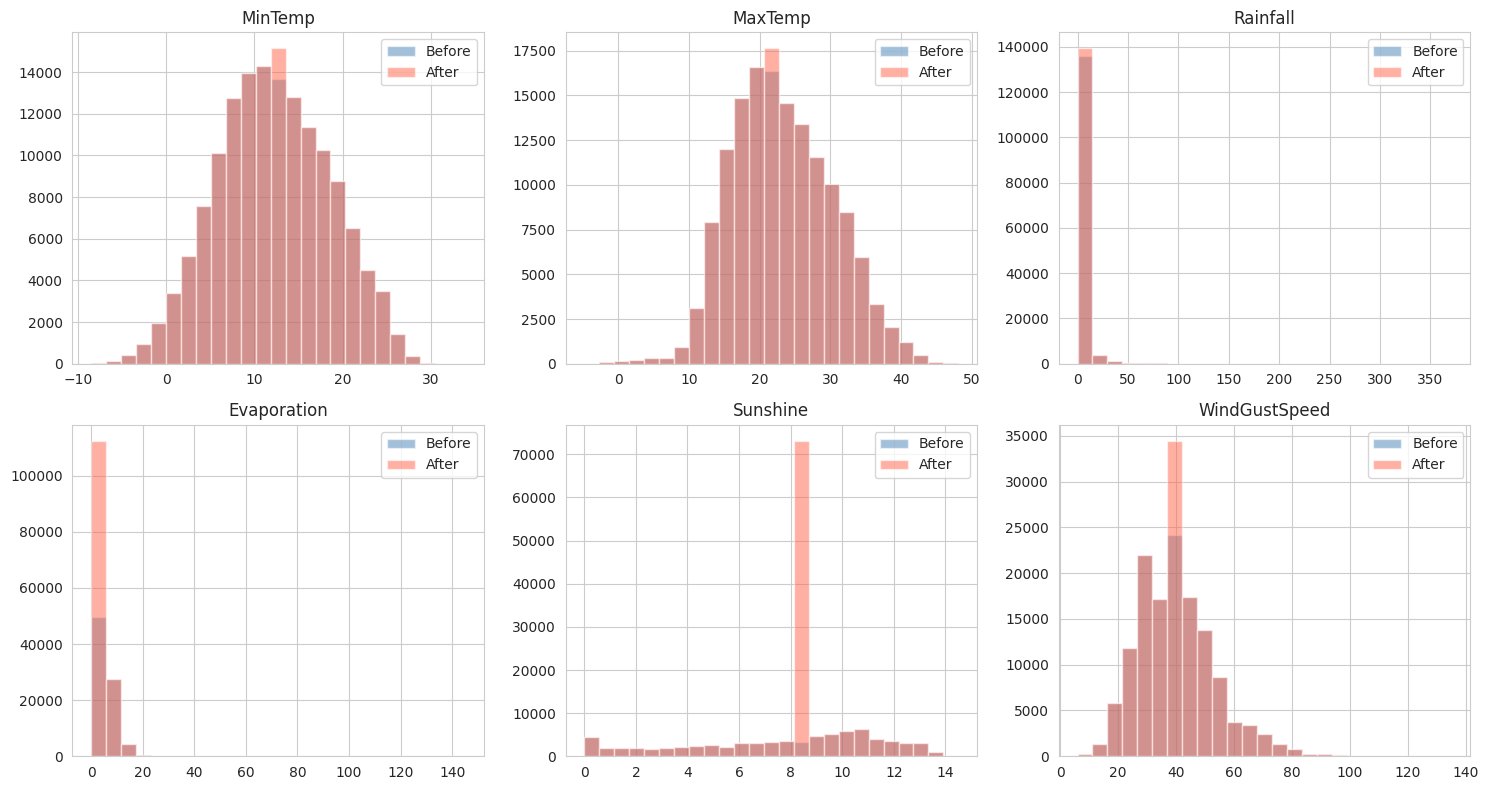

In [27]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
  if i>= 6: break
  if col in df.columns:
    axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
  if col in df_imputed.columns:
    axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
  axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

#5. Feature Engineering

In [37]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

Creating features...
After feature engineering: (145460, 35)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,DayOfWeek,Quarter,IsWeekend,TempRange,AvgHumidity,AvgPressure,AvgWindSpeed,PressureChange,HumidityChange
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No,2008,12,1,0,4,0,9.5,46.5,1007.40,22.0,0.6,49.0
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No,2008,12,2,1,4,0,17.7,34.5,1009.20,13.0,2.8,19.0
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No,2008,12,3,2,4,0,12.8,34.0,1008.15,22.5,-1.1,8.0
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No,2008,12,4,3,4,0,18.8,30.5,1015.20,10.0,4.8,29.0
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5,4,4,0,14.8,57.5,1008.40,13.5,4.8,49.0


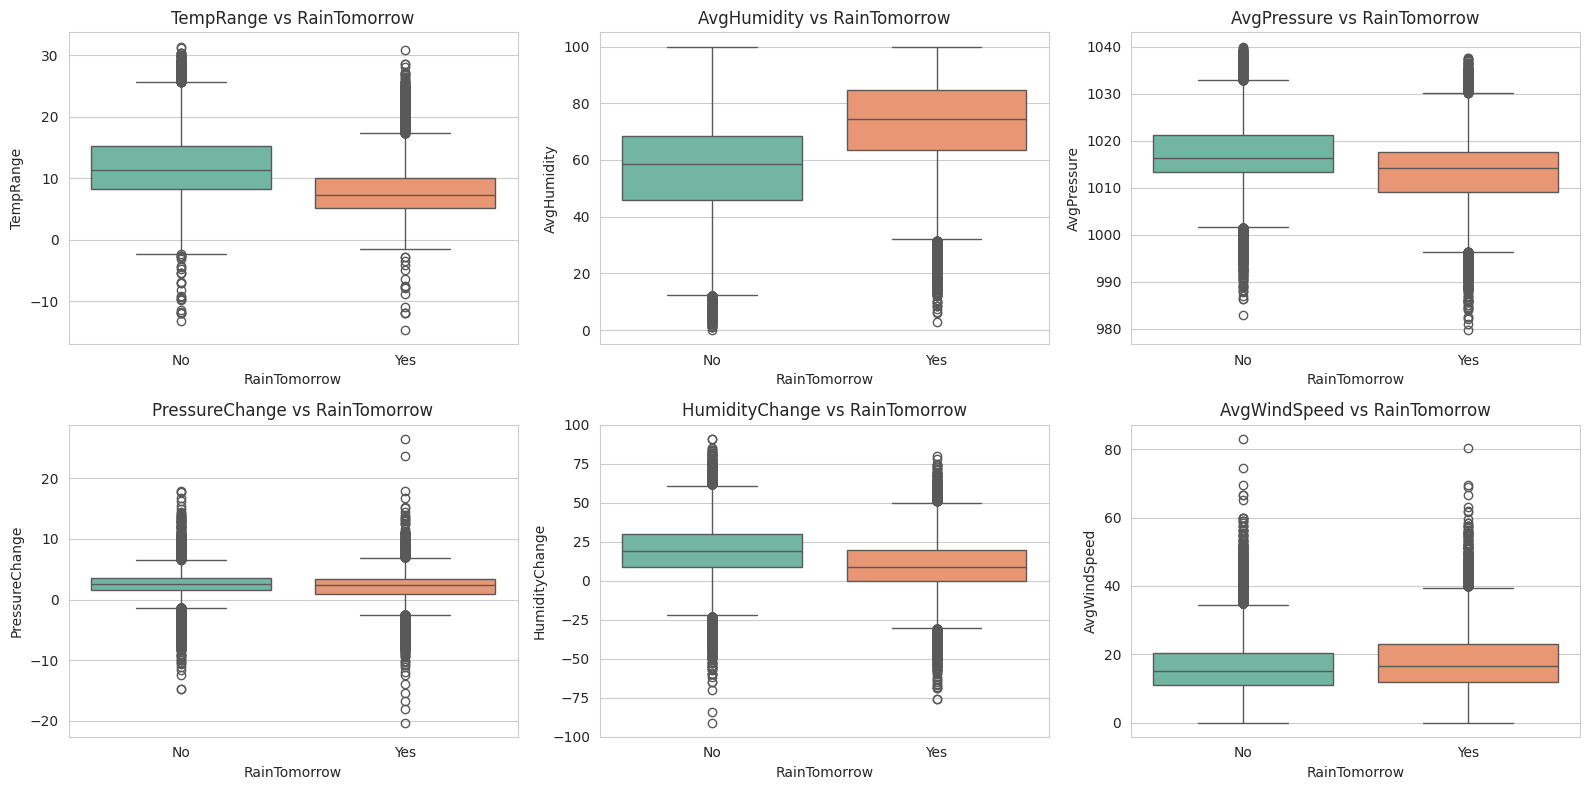

In [38]:
#Engineered features vs Target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['TempRange', 'AvgHumidity', 'AvgPressure',
                         'PressureChange', 'HumidityChange', 'AvgWindSpeed']):
  if col in df_feat.columns:
    sns.boxplot(x='RainTomorrow', y=col, data=df_feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs RainTomorrow')
plt.tight_layout(); plt.show()

#6. Encode Categorical Features

In [39]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('After one-hot encoding:', df_encoded.shape)

Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
After one-hot encoding: (145460, 124)


#7. Verify & Save Cleaned Dataset

In [43]:
print('Missing Values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)


Missing Values: 0
Final shape: (145460, 124)


In [47]:
from google.colab import files
df_encoded.to_csv('weatherAUS_cleaned.csv', index=False) # Save the DataFrame to a CSV file
files.download('weatherAUS_cleaned.csv')
df_encoded.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Year,Month,Day,DayOfWeek,Quarter,IsWeekend,TempRange,AvgHumidity,AvgPressure,AvgWindSpeed,PressureChange,HumidityChange,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,2008-12-01,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,2008,12,1,0,4,0,9.5,46.5,1007.40,22.0,0.6,49.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,2008-12-02,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,2008,12,2,1,4,0,17.7,34.5,1009.20,13.0,2.8,19.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,2008-12-03,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,2008,12,3,2,4,0,12.8,34.0,1008.15,22.5,-1.1,8.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2008-12-04,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,2008,12,4,3,4,0,18.8,30.5,1015.20,10.0,4.8,29.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008-12-05,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,2008,12,5,4,4,0,14.8,57.5,1008.40,13.5,4.8,49.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
